In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pickle
from matplotlib import pyplot as plt
import os
import arviz as az


import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import scipy.stats as stats



In [2]:
with open('gap_summary_2.pkl', 'rb') as f:
    gap_summary_2 = pickle.load(f)
thresh = gap_summary_2['thresh']
gap_summary = gap_summary_2['ntrade_seeds']


In [3]:
gap_summary.keys()

dict_keys(['100', '1100', '1400', '250', '500', '800'])

In [2]:
opt_results_path = '/nfs/home/dannis/AC-model/TIM_opt_results_20250622_032806/20250622_032806_20250620_162746_ntrade_500_nscenarios_500/opt_trace_500_gap_100_seed_100.pkl'
with open(opt_results_path, 'rb') as f:
    opt_results = pickle.load(f)
    

In [4]:
opt_results.keys()

dict_keys(['status', 'trades', 'obj_val', 'runtime', 'tail_prob', 'inventory', 'errors', 'kappa_samp', 'gamma_samp', 'rho_samp'])

In [8]:
trade1 = opt_results['trades']

In [4]:

# Base directory
base_dir = '/nfs/home/dannis/AC-model/TIM_opt_results_20250628'

# Storage for all trade data
all_trades = {}
file_info = []

# Iterate through subfolders
for subfolder in os.listdir(base_dir):
    subfolder_path = os.path.join(base_dir, subfolder)
    if os.path.isdir(subfolder_path):
        print(f"Processing subfolder: {subfolder}")
        
        # Iterate through files in subfolder
        for filename in os.listdir(subfolder_path):
            if filename.endswith('.pkl'):
                file_path = os.path.join(subfolder_path, filename)
                print(f"  Reading file: {filename}")
                
                try:
                    with open(file_path, 'rb') as f:
                        data = pickle.load(f)
                    
                    
                    # Extract key info from filename and subfolder
                    key = f"{subfolder}_{filename}"
                    all_trades[key] = data['trades']
                    file_info.append({
                        'key': key,
                        'subfolder': subfolder,
                        'filename': filename,
                        'trades': data['trades'],
                        'status': data.get('status', 'unknown'),
                    })
                        
                except Exception as e:
                    print(f"    Error reading {filename}: {e}")


Processing subfolder: 250_nscenarios_1000
  Reading file: opt_trace_250_gap_100_seed_104.pkl
  Reading file: opt_trace_250_gap_100_seed_100.pkl
  Reading file: opt_trace_250_gap_100_seed_101.pkl
  Reading file: opt_trace_250_gap_100_seed_107.pkl
  Reading file: opt_trace_250_gap_100_seed_106.pkl
  Reading file: opt_trace_250_gap_100_seed_105.pkl
  Reading file: opt_trace_250_gap_100_seed_111.pkl
  Reading file: opt_trace_250_gap_100_seed_108.pkl
  Reading file: opt_trace_250_gap_100_seed_112.pkl
  Reading file: opt_trace_250_gap_100_seed_110.pkl
  Reading file: opt_trace_250_gap_100_seed_103.pkl
  Reading file: opt_trace_250_gap_100_seed_109.pkl
  Reading file: opt_trace_250_gap_100_seed_114.pkl
  Reading file: opt_trace_250_gap_100_seed_113.pkl
  Reading file: opt_trace_250_gap_100_seed_102.pkl
Processing subfolder: 800_nscenarios_1000
  Reading file: opt_trace_800_gap_100_seed_112.pkl
  Reading file: opt_trace_800_gap_100_seed_104.pkl
  Reading file: opt_trace_800_gap_100_seed_118.pk

In [5]:
mean_trades = {}
sem_trades = {}
for ntrades, seeds in gap_summary.items():
    mean_trades[ntrades] = {}
    subfolder_name = f'{ntrades}_nscenarios_1000'
    for seed in seeds:
        filename = f'opt_trace_{ntrades}_gap_100_seed_{seed}.pkl'


In [6]:
import pandas as pd
# Plot all trade trajectories
# Initialize list to store data
data_rows = []

for i, info in enumerate(file_info):
    ntrades = info['filename'].split('_')[2]
    seed = info['filename'].split('_')[-1].split('.')[0]
    trades = np.array(info['trades'])
    if str(seed) in gap_summary[ntrades]:
        
        # Create a row with ntrades, seed, and each trade element as separate columns
        row = {
            'ntrades': ntrades,
            'seed': seed
        }
        
        # Add each trade element as a separate column (trade_0, trade_1, ..., trade_10)
        for j, trade in enumerate(trades):
            row[f'trade_{j}'] = trade
        
        data_rows.append(row)

# Create DataFrame
df = pd.DataFrame(data_rows)
    


In [7]:
df.ntrades.value_counts().sort_index()

ntrades
100      7
1100    12
1400    13
250      8
500     16
800     12
Name: count, dtype: int64

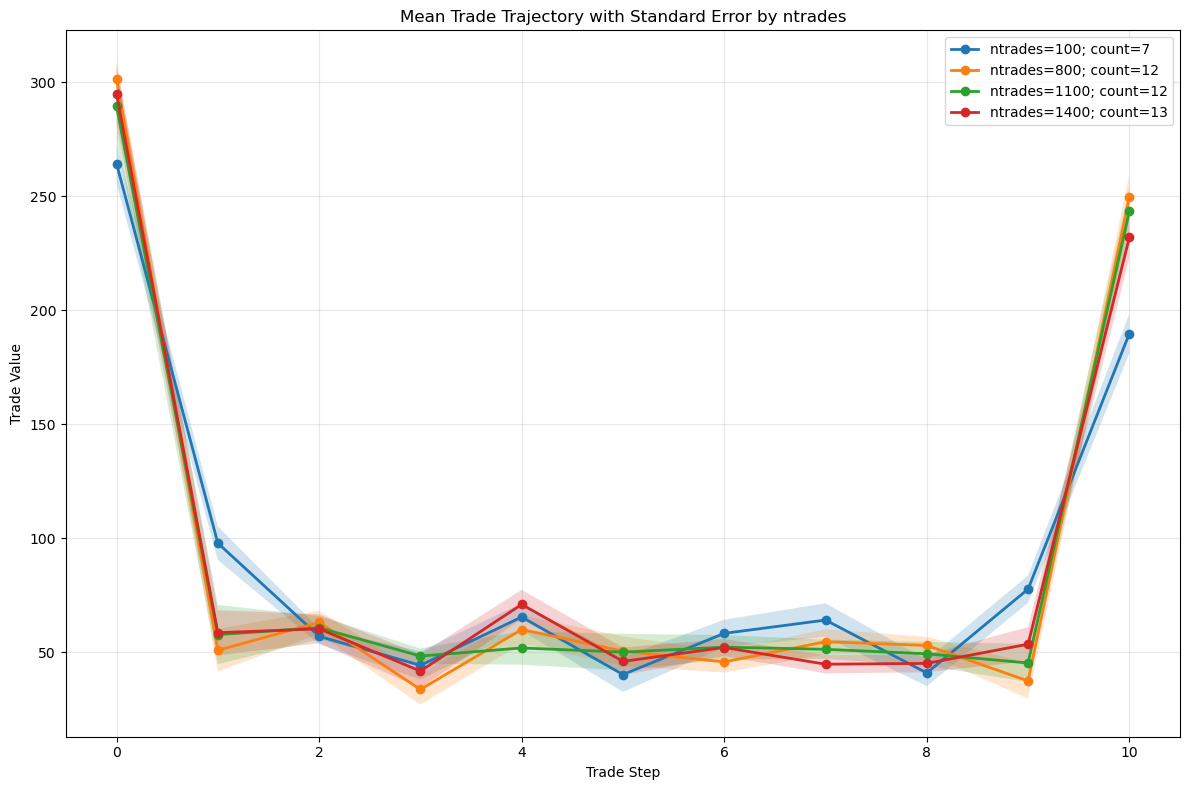

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Group by ntrades and calculate mean and standard error for each trade column
trade_cols = [f'trade_{j}' for j in range(11)]
ntrades_groups = df.groupby('ntrades')

plt.figure(figsize=(12, 8))

# Get unique ntrades values and sort them
ntrades_values = sorted(df['ntrades'].unique())

for ntrades in [ '100', '800', '1100', '1400']:
    group_data = ntrades_groups.get_group(ntrades)
    
    # Calculate mean and standard error for each trade column
    means = []
    std_errors = []
    
    for col in trade_cols:
        mean_val = group_data[col].mean()
        std_val = group_data[col].std()
        n_samples = len(group_data)
        std_error = std_val / np.sqrt(n_samples)
        
        means.append(mean_val)
        std_errors.append(std_error)
    
    means = np.array(means)
    std_errors = np.array(std_errors)
    x = np.arange(11)  # Trade steps 0 to 10
    
    # Plot mean trajectory
    plt.plot(x, means, marker='o', label=f'ntrades={ntrades}; count={len(gap_summary[ntrades])}', linewidth=2)
    
    # Add standard error bands
    plt.fill_between(x, means - std_errors, means + std_errors, alpha=0.2)

plt.xlabel('Trade Step')
plt.ylabel('Trade Value')
plt.title('Mean Trade Trajectory with Standard Error by ntrades')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# find the total lengths of all values in gap_summary
total_lengths = np.sum(len(v) for v in gap_summary.values())
print(total_lengths)

61


/tmp/ipykernel_574474/1642390961.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  total_lengths = np.sum(len(v) for v in gap_summary.values())


In [ ]:
plt.figure(figsize=(15, 10))
if info['status'] == 2:
    linestyle = 'solid'
else:
    linestyle = 'dashed'
print(info['status'])
plt.plot(trades, label=f"{info['filename']}", alpha=0.7, linestyle=linestyle)

plt.title('Trade Trajectories from All Pickle Files')
plt.xlabel('Time Step')
plt.ylabel('Trade Size')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary:")
print(f"Total files processed: {len(file_info)}")
print(f"Subfolders found: {len(set([info['subfolder'] for info in file_info]))}")

# Plot by subfolder
# subfolders = list(set([info['subfolder'] for info in file_info]))
# fig, axes = plt.subplots(len(subfolders), 1, figsize=(15, 5*len(subfolders)))
# if len(subfolders) == 1:
#     axes = [axes]

# for i, subfolder in enumerate(subfolders):
#     ax = axes[i] if len(subfolders) > 1 else axes
#     subfolder_files = [info for info in file_info if info['subfolder'] == subfolder]
    
#     for info in subfolder_files:
#         trades = np.array(info['trades'])
#         ax.plot(trades, label=info['filename'], alpha=0.7)
    
#     ax.set_title(f'Trade Trajectories - {subfolder}')
#     ax.set_xlabel('Time Step')
#     ax.set_ylabel('Trade Size')
#     ax.legend()
#     ax.grid(True)

# plt.tight_layout()
# plt.show()